# Business Problem
An Online travel booking company is suffering from loss in revenue because of the uncertain booking cancelation of its customers. The company wants to know which customer will cancel the booking.

# Dataset Detailes

0   hotel (H1 = Resort Hotel or H2 = City Hotel)

1   is_canceled Value indicating if the booking was canceled (1) or not (0)

2   lead_time Number of days that elapsed between the entering date of the booking into the PMS and the arrival date

3   arrival_date_year Year of arrival date

4   arrival_date_month Month of arrival date

5   arrival_date_week_number Week number of year for arrival date

6   arrival_date_day_of_month Day of arrival date

7   stays_in_weekend_nights Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel

8   stays_in_week_nights Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel

9   adults Number of adults

10  children Number of children

11  babies Number of babies

12  meal Type of meal booked. Categories are presented in standard hospitality meal packages: Undefined/SC – no meal

13  country Country of origin. Categories are represented in the ISO 3155–3:2013 format

14  market_segment Market segment designation. In categories, the term “TA” means “Travel Agents” and “TO” means “Tour Operators”

15  distribution_channel Booking distribution channel. The term “TA” means “Travel Agents” and “TO” means “Tour Operators”

16  is_repeated_guest Value indicating if the booking name was from a repeated guest (1) or not (0)

17  previous_cancellations Number of previous bookings that were cancelled by the customer prior to the current booking

18  previous_bookings_not_canceled Number of previous bookings not cancelled by the customer prior to the current booking

19  reserved_room_type Code of room type reserved. Code is presented instead of designation for anonymity reasons.

20  assigned_room_typeCode for the type of room assigned to the booking.Code is presented instead of designation for anonymity reasons.

21  booking_changes Number of changes made to the booking from the moment the booking was entered on the PMS until the moment of check-in or out

22  deposit_type Indication on if the customer made a deposit to guarantee the booking. This variable can assume three categories: No

23  agent ID of the travel agency that made the booking

24  company ID of the company that made the booking or responsible for paying the booking.

25  days_in_waiting_list Number of days the booking was in the waiting list before it was confirmed to the customer

26  customer_type Type of booking, assuming one of four categories:Transient - Transient-Party - Contract - Group

27  adr Average Daily Rate as defined by dividing the sum of all lodging transactions by the total number of staying nights

28  required_car_parking_spaces Number of car parking spaces required by the customer

29  total_of_special_requestsNumber of special requests made by the customer (e.g. twin bed or high floor)

30  reservation_status Reservation last status, assuming one of three categories: Canceled – booking was canceled by the customer; Check-Out

31  reservation_status_date Date at which the last status was set. This variable can be used in conjunction with the ReservationStatus to

# Importing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import HeatMap
import plotly.express as px

!pip install sort-dataframeby-monthorweek
!pip install sorted-months-weekdays


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


  Preparing metadata (setup.py) ... - \ done
  Created wheel for sort-dataframeby-monthorweek: filename=sort_dataframeby_monthorweek-0.4-py3-none-any.whl size=3440 sha256=d8b23807c4b66b126fc92deb4198b551205d36b83889ac43f9acc238947ac985
  Stored in directory: /root/.cache/pip/wheels/6b/fd/39/06eaac8d65d641f9f50856a48b57a5ec8351be2874beff01ec
Successfully built sort-dataframeby-monthorweek
  Preparing metadata (setup.py) ... - done
  Created wheel for sorted-months-weekdays: filename=sorted_months_weekdays-0.2-py3-none-any.whl size=3247 sha256=b5306d873ca62e9b0e87b86dae28bf667864bc3c1447de2ac9192bed18b65764
  Stored in directory: /root/.cache/pip/wheels/bd/b4/f6/2c29a96668a9a13a568134857fd7b7a5186261f00f1d35661c
Successfully built sorted-months-weekdays


In [2]:
#Load data
data=pd.read_csv("/kaggle/input/hotel-booking-demand/hotel_bookings.csv")
data.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [3]:
data.shape

(119390, 32)

# Data Analysis

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
data.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
data['country'].fillna('PRT',inplace=True)
data.fillna(0,inplace=True)
data.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [8]:
# adults, babies and children cant be zero at same time, so dropping the rows having all these zero at same time

filter = (data.children == 0) & (data.adults == 0) & (data.babies == 0)
data[filter]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,No Deposit,0.0,174.0,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,No Deposit,0.0,174.0,0,Transient,0.00,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,No Deposit,38.0,0.0,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,No Deposit,308.0,0.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,No Deposit,308.0,0.0,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,City Hotel,0,107,2017,June,26,27,0,3,0,...,No Deposit,7.0,0.0,0,Transient,100.80,0,0,Check-Out,2017-06-30
115091,City Hotel,0,1,2017,June,26,30,0,1,0,...,No Deposit,0.0,0.0,0,Transient,0.00,1,1,Check-Out,2017-07-01
116251,City Hotel,0,44,2017,July,28,15,1,1,0,...,No Deposit,425.0,0.0,0,Transient,73.80,0,0,Check-Out,2017-07-17
116534,City Hotel,0,2,2017,July,28,15,2,5,0,...,No Deposit,9.0,0.0,0,Transient-Party,22.86,0,1,Check-Out,2017-07-22


In [9]:
is_can = len(data[data['is_canceled']==1])
print("Percentage cancelation= ", is_can/len(data))
data['reservation_status'].value_counts(normalize=True)*100

Percentage cancelation=  0.37041628277075134


Check-Out    62.958372
Canceled     36.030656
No-Show       1.010972
Name: reservation_status, dtype: float64

Number of guest in each hotels

# Exploratory Data Analysis (EDA)

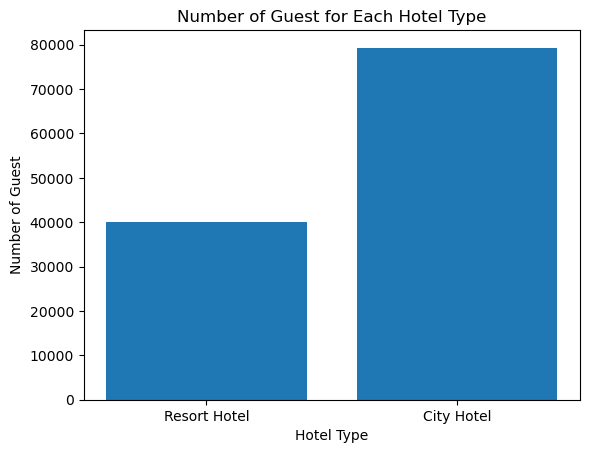

In [10]:
resort_len= len(data[data['hotel']=='Resort Hotel'])
city_len=len(data[data['hotel']=='City Hotel'])

hotel_types = ['Resort Hotel', 'City Hotel']
lengths = [resort_len, city_len]

plt.bar(hotel_types, lengths)
plt.xlabel('Hotel Type')
plt.ylabel('Number of Guest')
plt.title('Number of Guest for Each Hotel Type')
plt.show()


In [11]:
country_wise_counts = data[data['is_canceled'] == 0]['country'].value_counts().reset_index()
country_wise_counts.columns = ['country', 'No of guests']
country_wise_counts

,country,No of guests
0,PRT,21492
1,GBR,9676
2,FRA,8481
3,ESP,6391
4,DEU,6069
...,...,...
160,BHR,1
161,DJI,1
162,MLI,1
163,NPL,1


In [12]:
basemap = folium.Map()
guests_map = px.choropleth(country_wise_counts, locations = country_wise_counts['country'],
                           color = country_wise_counts['No of guests'], hover_name = country_wise_counts['country'])
guests_map.show()

Most guests are from Portugal and other countries in Europe.

In [13]:
df = data[data['is_canceled'] == 0]
px.box(data_frame = df, x = 'reserved_room_type', y = 'adr', color = 'hotel', template = 'plotly_dark')

The figure shows that avgerage price per room

In [14]:
data_resort = data[(data['hotel'] == 'Resort Hotel') & (data['is_canceled'] == 0)]
data_city = data[(data['hotel'] == 'City Hotel') & (data['is_canceled'] == 0)]

In [15]:
resort_hotel = data_resort.groupby(['arrival_date_month'])['adr'].mean().reset_index()
resort_hotel

,arrival_date_month,adr
0,April,75.867816
1,August,181.205892
2,December,68.322236
3,February,54.147478
4,January,48.708919
5,July,150.122528
6,June,107.921869
7,March,57.012487
8,May,76.657558
9,November,48.681640


In [16]:
city_hotel = data_city.groupby(['arrival_date_month'])['adr'].mean().reset_index()
city_hotel

,arrival_date_month,adr
0,April,111.856824
1,August,118.412083
2,December,87.856764
3,February,86.183025
4,January,82.160634
5,July,115.563810
6,June,117.702075
7,March,90.170722
8,May,120.445842
9,November,86.500456


In [17]:
final_hotel = resort_hotel.merge(city_hotel, on = 'arrival_date_month')
final_hotel.columns = ['month', 'price_for_resort', 'price_for_city_hotel']
final_hotel

,month,price_for_resort,price_for_city_hotel
0,April,75.867816,111.856824
1,August,181.205892,118.412083
2,December,68.322236,87.856764
3,February,54.147478,86.183025
4,January,48.708919,82.160634
5,July,150.122528,115.563810
6,June,107.921869,117.702075
7,March,57.012487,90.170722
8,May,76.657558,120.445842
9,November,48.681640,86.500456


In [18]:
import sort_dataframeby_monthorweek as sd

def sort_month(df, column_name):
    return sd.Sort_Dataframeby_Month(df, column_name)

In [19]:
final_prices = sort_month(final_hotel, 'month')
final_prices

,month,price_for_resort,price_for_city_hotel
0,January,48.708919,82.160634
1,February,54.147478,86.183025
2,March,57.012487,90.170722
3,April,75.867816,111.856824
4,May,76.657558,120.445842
5,June,107.921869,117.702075
6,July,150.122528,115.563810
7,August,181.205892,118.412083
8,September,96.416860,112.598452
9,October,61.727505,101.745956


In [20]:
plt.figure(figsize = (19, 10))

px.line(final_prices, x = 'month', y = ['price_for_resort','price_for_city_hotel'],
        title = 'Room price per night over the Months', template = 'plotly_dark')

<Figure size 1900x1000 with 0 Axes>

Resort_Hotel- expensive in augest month  //  
City_Hotel- expensive in may month

In [21]:
filter=data["is_canceled"]==0
df=data[filter]
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [22]:
df['total_night']=df['stays_in_weekend_nights']+df['stays_in_week_nights']
df

/tmp/ipykernel_20/674593334.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_night
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0.0,0,Transient,0.00,0,0,Check-Out,2015-07-01,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,0.0,0,Transient,0.00,0,0,Check-Out,2015-07-01,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0.0,0.0,0,Transient,75.00,0,0,Check-Out,2015-07-02,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304.0,0.0,0,Transient,75.00,0,0,Check-Out,2015-07-02,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,0.0,0,Transient,98.00,0,1,Check-Out,2015-07-03,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,394.0,0.0,0,Transient,96.14,0,0,Check-Out,2017-09-06,7
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,9.0,0.0,0,Transient,225.43,0,2,Check-Out,2017-09-07,7
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,9.0,0.0,0,Transient,157.71,0,4,Check-Out,2017-09-07,7
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,89.0,0.0,0,Transient,104.40,0,0,Check-Out,2017-09-07,7


In [23]:
stay = df.groupby(['total_night', 'hotel']).agg('count').reset_index()
stay = stay.iloc[:, :3]
stay = stay.rename(columns={'is_canceled':'Number of stays'})
stay

,total_night,hotel,Number of stays
0,0,City Hotel,308
1,0,Resort Hotel,372
2,1,City Hotel,9169
3,1,Resort Hotel,6580
4,2,City Hotel,10992
...,...,...,...
63,49,City Hotel,1
64,56,Resort Hotel,1
65,57,City Hotel,1
66,60,Resort Hotel,1


In [24]:
px.bar(data_frame = stay, x = 'total_night', y = 'Number of stays', color = 'hotel', barmode = 'group',
        template = 'plotly_dark')

<Axes: xlabel='market_segment', ylabel='stays_in_weekend_nights'>

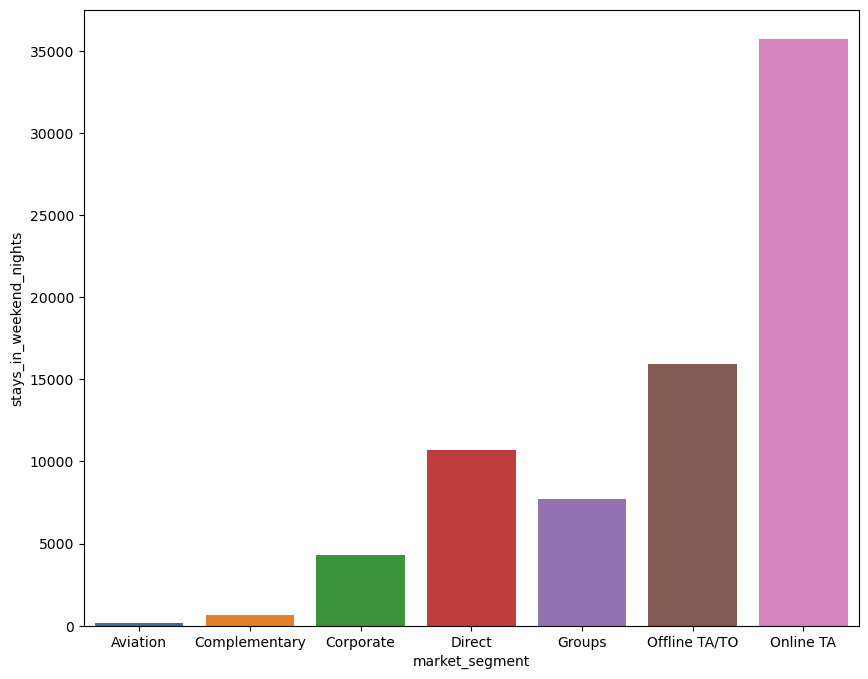

In [25]:
plt.figure(figsize=(10,8))
sns.barplot(x=data[data['is_canceled']==0].groupby('market_segment')['stays_in_weekend_nights'].count().index,
            y=data[data['is_canceled']==0].groupby('market_segment')['stays_in_weekend_nights'].count())

# Data Preprocessing

/tmp/ipykernel_20/3720143643.py:3: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



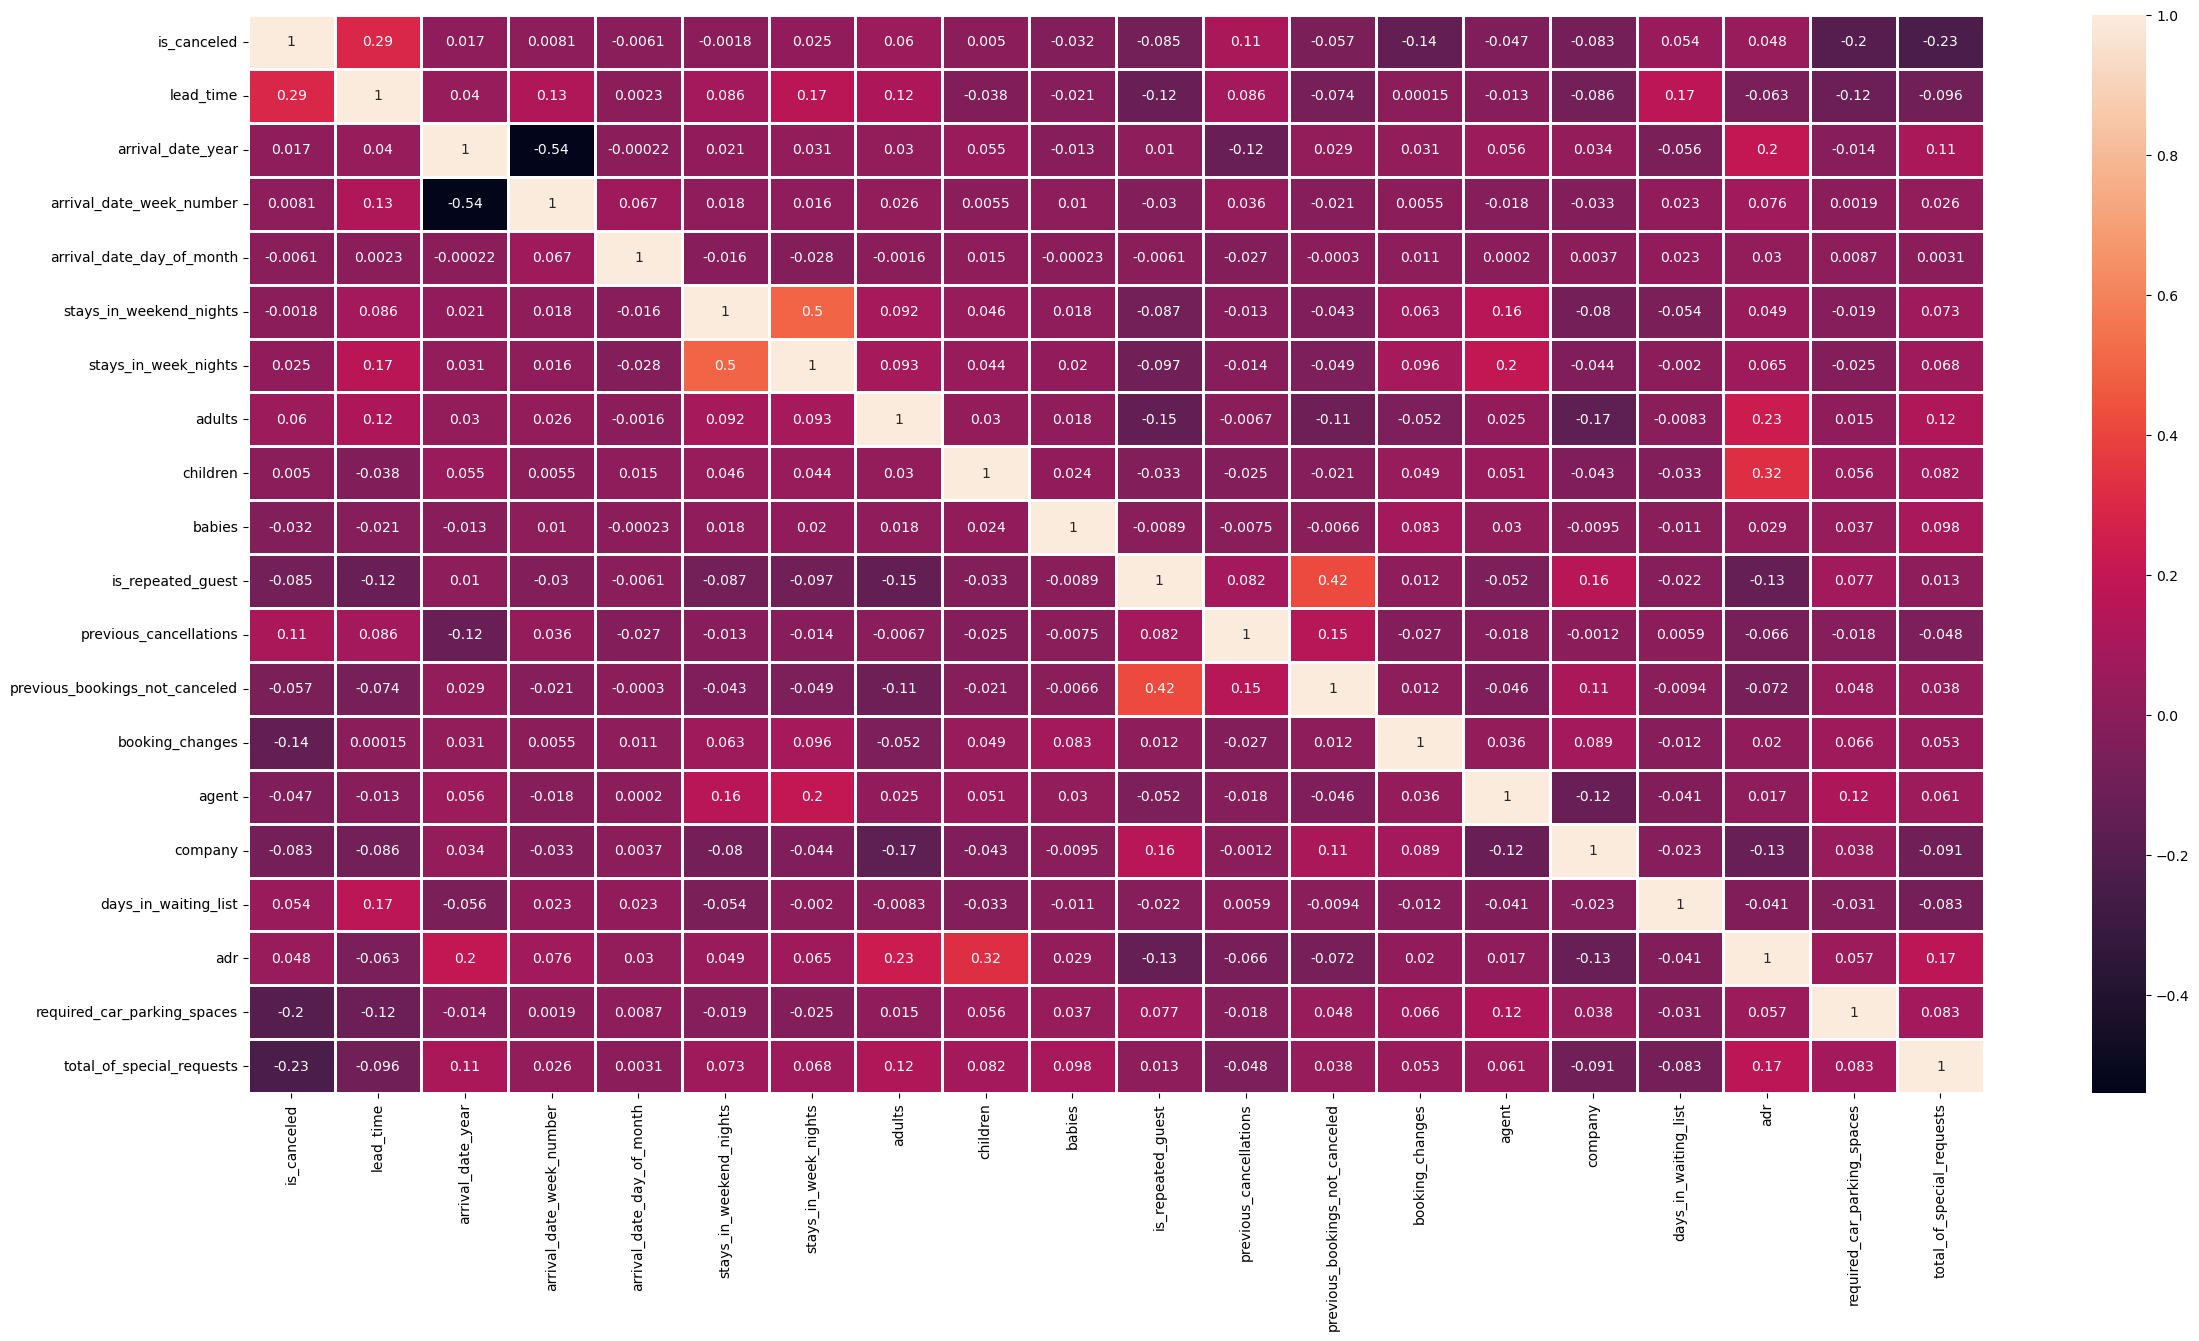

In [26]:
plt.figure(figsize = (28, 14))

corr = data.corr()
sns.heatmap(corr, annot = True, linewidths = 1)
plt.show()

In [27]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [28]:
data = data.drop_duplicates()
len(df)

75166

In [29]:
label = ['company','agent','total_of_special_requests','required_car_parking_spaces','booking_changes',
         'is_repeated_guest','reservation_status_date','stays_in_weekend_nights','stays_in_week_nights',
         'reserved_room_type','assigned_room_type','adults','children','babies']
data.drop(labels=label,axis=1,inplace=True)
data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,meal,country,market_segment,distribution_channel,previous_cancellations,previous_bookings_not_canceled,deposit_type,days_in_waiting_list,customer_type,adr,reservation_status
0,Resort Hotel,0,342,2015,July,27,1,BB,PRT,Direct,Direct,0,0,No Deposit,0,Transient,0.00,Check-Out
1,Resort Hotel,0,737,2015,July,27,1,BB,PRT,Direct,Direct,0,0,No Deposit,0,Transient,0.00,Check-Out
2,Resort Hotel,0,7,2015,July,27,1,BB,GBR,Direct,Direct,0,0,No Deposit,0,Transient,75.00,Check-Out
3,Resort Hotel,0,13,2015,July,27,1,BB,GBR,Corporate,Corporate,0,0,No Deposit,0,Transient,75.00,Check-Out
4,Resort Hotel,0,14,2015,July,27,1,BB,GBR,Online TA,TA/TO,0,0,No Deposit,0,Transient,98.00,Check-Out
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,BB,BEL,Offline TA/TO,TA/TO,0,0,No Deposit,0,Transient,96.14,Check-Out
119386,City Hotel,0,102,2017,August,35,31,BB,FRA,Online TA,TA/TO,0,0,No Deposit,0,Transient,225.43,Check-Out
119387,City Hotel,0,34,2017,August,35,31,BB,DEU,Online TA,TA/TO,0,0,No Deposit,0,Transient,157.71,Check-Out
119388,City Hotel,0,109,2017,August,35,31,BB,GBR,Online TA,TA/TO,0,0,No Deposit,0,Transient,104.40,Check-Out


In [30]:
X = data.drop(['is_canceled'],axis=1)
y = data['is_canceled']

In [31]:
X = pd.get_dummies(X,drop_first=True)


In [32]:
X.shape, y.shape

((87377, 218), (87377,))

In [33]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

# LogisticRegression Model

In [35]:
# LogisticRegression
log = LogisticRegression(solver='liblinear')
log.fit(X_train,y_train)
#Print the model accuracy of training data
print('Logistic Regression Training Accuracy : ',log.score(X_train, y_train))

Logistic Regression Training Accuracy :  1.0


In [36]:
cm = confusion_matrix(y_test,log.predict(X_test))
print(cm)
print('Accuracy ',accuracy_score(y_test,log.predict(X_test)))

[[15894     0]
 [    0  5951]]
Accuracy  1.0


# 100% Accuracy

In [37]:
print(classification_report(y_test,log.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15894
           1       1.00      1.00      1.00      5951

    accuracy                           1.00     21845
   macro avg       1.00      1.00      1.00     21845
weighted avg       1.00      1.00      1.00     21845

